# **CHALLENGE TELCOM X PARTE 2**

🎯 **Misión**

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.

## 🛠️ **PREPARACIÓN DE LOS DATOS**

### **Extracción del Archivo Tratado**

Del anterior Challenge (Parte 1) se tiene dos archicos CSV que se usaran como archivos tratados:

1. **Data.csv:** Contiene todas las columnas con la signularidad de que los datos contienen strings en las respuesta binaria (SI Y NO).
2. **Data_binaria.csv:** Los datos tiene tratamiento Binario pasando los strings a (0 Y 1).

In [8]:
import pandas as pd

In [9]:
Data = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/ALURA/Challenge Telcom_X/PARTE 2/Data.csv')
Data_binaria = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/ALURA/Challenge Telcom_X/PARTE 2/Data_binaria.csv')

In [10]:
Data.head()

,ID_cliente,Permanencia,Genero_cliente,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Internet,...,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Tipo_Contrato,Preferencia_Factura,Metodo_de_Pago,Gasto_Mensual,Gasto_Total,Cuentas_Diarias
0,0002-ORFBO,no,female,0,yes,yes,9,yes,no,dsl,...,no,yes,yes,no,one year,yes,mailed check,65.6,593.30,2.19
1,0003-MKNFE,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,yes,month-to-month,no,mailed check,59.9,542.40,2.00
2,0004-TLHLJ,yes,male,0,no,no,4,yes,no,fiber optic,...,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85,2.46
3,0011-IGKFF,yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,yes,female,1,yes,no,3,yes,no,fiber optic,...,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.40,2.80


In [11]:
Data_binaria.head()

,ID_cliente,Permanencia,Genero_cliente,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Internet,...,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Tipo_Contrato,Preferencia_Factura,Metodo_de_Pago,Gasto_Mensual,Gasto_Total,Cuentas_Diarias
0,0002-ORFBO,0,female,0,1,1,9,1,0,dsl,...,0,1,1,0,one year,1,mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,male,0,0,0,9,1,1,dsl,...,0,0,0,1,month-to-month,0,mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,male,0,0,0,4,1,0,fiber optic,...,1,0,0,0,month-to-month,1,electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,male,1,1,0,13,1,0,fiber optic,...,1,0,1,1,month-to-month,1,electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,female,1,1,0,3,1,0,fiber optic,...,0,1,1,0,month-to-month,1,mailed check,83.9,267.40,2.80


### **Eliminación de Columnas Irrelevantes**

Trabajaremos con el csv Binario por facilidad númerica y estadistica necesaria de los datos

In [12]:
df = Data_binaria.copy()
columns_to_drop = ['ID_cliente'] #Elimanos la columna
df = df.drop(columns=columns_to_drop)

df.head()

,Permanencia,Genero_cliente,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Internet,Sus_Seguridad_online,...,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Tipo_Contrato,Preferencia_Factura,Metodo_de_Pago,Gasto_Mensual,Gasto_Total,Cuentas_Diarias
0,0,female,0,1,1,9,1,0,dsl,0,...,0,1,1,0,one year,1,mailed check,65.6,593.30,2.19
1,0,male,0,0,0,9,1,1,dsl,0,...,0,0,0,1,month-to-month,0,mailed check,59.9,542.40,2.00
2,1,male,0,0,0,4,1,0,fiber optic,0,...,1,0,0,0,month-to-month,1,electronic check,73.9,280.85,2.46
3,1,male,1,1,0,13,1,0,fiber optic,0,...,1,0,1,1,month-to-month,1,electronic check,98.0,1237.85,3.27
4,1,female,1,1,0,3,1,0,fiber optic,0,...,0,1,1,0,month-to-month,1,mailed check,83.9,267.40,2.80


### **Encoding**

In [13]:
df_encoding = df.copy()
df_encoding= pd.get_dummies(df, columns=['Genero_cliente', 'Sus_Internet', 'Tipo_Contrato', 'Metodo_de_Pago'])
pd.set_option('display.max_columns', None)
df_encoding.head()

,Permanencia,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Seguridad_online,Sus_Respaldo_online,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Preferencia_Factura,Gasto_Mensual,Gasto_Total,Cuentas_Diarias,Genero_cliente_female,Genero_cliente_male,Sus_Internet_dsl,Sus_Internet_fiber optic,Sus_Internet_no,Tipo_Contrato_month-to-month,Tipo_Contrato_one year,Tipo_Contrato_two year,Metodo_de_Pago_bank transfer (automatic),Metodo_de_Pago_credit card (automatic),Metodo_de_Pago_electronic check,Metodo_de_Pago_mailed check
0,0,0,1,1,9,1,0,0,1,0,1,1,0,1,65.6,593.30,2.19,True,False,True,False,False,False,True,False,False,False,False,True
1,0,0,0,0,9,1,1,0,0,0,0,0,1,0,59.9,542.40,2.00,False,True,True,False,False,True,False,False,False,False,False,True
2,1,0,0,0,4,1,0,0,0,1,0,0,0,1,73.9,280.85,2.46,False,True,False,True,False,True,False,False,False,False,True,False
3,1,1,1,0,13,1,0,0,1,1,0,1,1,1,98.0,1237.85,3.27,False,True,False,True,False,True,False,False,False,False,True,False
4,1,1,1,0,3,1,0,0,0,0,1,1,0,1,83.9,267.40,2.80,True,False,False,True,False,True,False,False,False,False,False,True


Las columnas 'Genero_cliente', 'Sus_Internet', 'Tipo_Contrato' y 'Metodo_de_Pago' fueron seleccionadas porque son columnas categóricas de tipo nominal. Esto significa que sus valores son etiquetas o nombres que representan categorías distintas, sin un orden intrínseco entre ellas.

El 'one-hot encoding' resuelve esto creando nuevas columnas binarias (0 o 1) para cada categoría única en la columna original


### **Verificación de la Proporción de Cancelación (Churn)**

In [14]:
churn_proportion = df_encoding['Permanencia'].value_counts(normalize=True)
print("Proporción de clientes por estado de permanencia:")
print(churn_proportion * 100)

Proporción de clientes por estado de permanencia:
Permanencia
0             71.198569
1             25.719004
no reporta     3.082427
Name: proportion, dtype: float64


### **Balanceo de Clases**

Eliminar las filas donde 'Permanencia' es 'no reporta' del conjunto de datos, ya que no representan un estado claro de cancelación para el modelado.


In [15]:
print(f"Shape before filtering: {df_encoding.shape}")
df_encoding = df_encoding[df_encoding['Permanencia'] != 'no reporta']
print(f"Shape after filtering: {df_encoding.shape}")
df_encoding.head()

Shape before filtering: (7267, 29)
Shape after filtering: (7043, 29)


,Permanencia,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Seguridad_online,Sus_Respaldo_online,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Preferencia_Factura,Gasto_Mensual,Gasto_Total,Cuentas_Diarias,Genero_cliente_female,Genero_cliente_male,Sus_Internet_dsl,Sus_Internet_fiber optic,Sus_Internet_no,Tipo_Contrato_month-to-month,Tipo_Contrato_one year,Tipo_Contrato_two year,Metodo_de_Pago_bank transfer (automatic),Metodo_de_Pago_credit card (automatic),Metodo_de_Pago_electronic check,Metodo_de_Pago_mailed check
0,0,0,1,1,9,1,0,0,1,0,1,1,0,1,65.6,593.30,2.19,True,False,True,False,False,False,True,False,False,False,False,True
1,0,0,0,0,9,1,1,0,0,0,0,0,1,0,59.9,542.40,2.00,False,True,True,False,False,True,False,False,False,False,False,True
2,1,0,0,0,4,1,0,0,0,1,0,0,0,1,73.9,280.85,2.46,False,True,False,True,False,True,False,False,False,False,True,False
3,1,1,1,0,13,1,0,0,1,1,0,1,1,1,98.0,1237.85,3.27,False,True,False,True,False,True,False,False,False,False,True,False
4,1,1,1,0,3,1,0,0,0,0,1,1,0,1,83.9,267.40,2.80,True,False,False,True,False,True,False,False,False,False,False,True


In [16]:
X = df_encoding.drop('Permanencia', axis=1)
y = df_encoding['Permanencia'].astype(int)

print("Features (X) head:")
print(X.head())
print("\nTarget (y) head:")
print(y.head())

Features (X) head:
   Cliente_Tercera_Edad  Pareja_Cliente  Dependientes_del_Cliente  \
0                     0               1                         1   
1                     0               0                         0   
2                     0               0                         0   
3                     1               1                         0   
4                     1               1                         0   

   Meses_del_Contrato  Servicio_telefonico  Multiples_lineas_telefonicas  \
0                   9                    1                             0   
1                   9                    1                             1   
2                   4                    1                             0   
3                  13                    1                             0   
4                   3                    1                             0   

   Sus_Seguridad_online  Sus_Respaldo_online  Sus_Protección_al_Dispositivo  \
0                     0       

Ahora que las características (X) y el objetivo (y) se han separado y la variable objetivo es numérica, aplicaré la técnica SMOTE para equilibrar las clases en la variable objetivo. Esto implica importar SMOTE, instanciarlo y, a continuación, remuestrear los datos.


El DataFrame contiene valores NaN. Necesito identificar y gestionar estos valores faltantes antes de aplicar SMOTE. Comprobaré si hay valores NaN en y luego los imputaré utilizando la estrategia de media para asegurar que no contenga NaN, lo cual es un requisito previo para SMOTE.

In [17]:
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
import numpy as np

# Comprobar valores NaN
print("Valores NaN antes de la imputación:")
print(X.isnull().sum()[X.isnull().sum() > 0])

# Imputar valores NaN en el df utilizando la estrategia de media
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Verificar que no haya más valores NaN
print("\nValores NaN después de la imputación:")
print(X_imputed.isnull().sum()[X_imputed.isnull().sum() > 0])

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_imputed, y)

print("\nProporción de clientes por estado de permanencia después de SMOTE:")
print(y_resampled.value_counts(normalize=True) * 100)

Valores NaN antes de la imputación:
Gasto_Total    11
dtype: int64

Valores NaN después de la imputación:
Series([], dtype: int64)

Proporción de clientes por estado de permanencia después de SMOTE:
Permanencia
0    50.0
1    50.0
Name: proportion, dtype: float64


- El conjunto de datos df_encoding contenía 7267 filas. Tras filtrar las filas donde "Permanencia" era "no reporta", se eliminaron 224 filas, reduciendo el conjunto de datos a 7043.

- Se identificó que la columna "Gasto_Total" tenía 11 valores faltantes (NaN), que posteriormente se imputaron mediante la estrategia de media.

- Tras aplicar la técnica SMOTE, la variable objetivo "Permanencia" alcanzó una distribución de clases perfectamente equilibrada, donde ambas clases (0 y 1) representan el 50% del conjunto de datos.

In [18]:
datos_post_Balanceo = X_resampled.copy()
datos_post_Balanceo['Permanencia'] = y_resampled
datos_post_Balanceo.head()

,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Seguridad_online,Sus_Respaldo_online,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Preferencia_Factura,Gasto_Mensual,Gasto_Total,Cuentas_Diarias,Genero_cliente_female,Genero_cliente_male,Sus_Internet_dsl,Sus_Internet_fiber optic,Sus_Internet_no,Tipo_Contrato_month-to-month,Tipo_Contrato_one year,Tipo_Contrato_two year,Metodo_de_Pago_bank transfer (automatic),Metodo_de_Pago_credit card (automatic),Metodo_de_Pago_electronic check,Metodo_de_Pago_mailed check,Permanencia
0,0.0,1.0,1.0,9.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,65.6,593.30,2.19,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
1,0.0,0.0,0.0,9.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,59.9,542.40,2.00,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0
2,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,73.9,280.85,2.46,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
3,1.0,1.0,0.0,13.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,98.0,1237.85,3.27,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
4,1.0,1.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,83.9,267.40,2.80,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1


### **Normalización o Estandarización**

La normalización de los datos garantiza que todas las variables contribuyan en igualdad de condiciones al proceso de modelado. En modelos basados en distancia, como KNN, la magnitud de las variables influye directamente en el cálculo de la distancia entre observaciones. Si las variables no están escaladas, aquellas con mayor rango numérico pueden dominar la métrica de distancia e introducir un sesgo en la clasificación.

Al aplicar una normalización (por ejemplo, mediante MinMaxScaler), todas las variables se reescalan a un mismo rango —habitualmente entre 0 y 1—, lo que evita que aquellas con valores numéricos más altos dominen el proceso de aprendizaje. De esta manera, la magnitud original de cada variable no determina su influencia en modelos basados en distancia (como KNN) o en optimización de parámetros (como la regresión logística o las redes neuronales).

En contraste, los modelos basados en árboles no requieren normalización, ya que realizan particiones mediante umbrales y no dependen de métricas de distancia.

Identificar las columnas de tipo numérico en `X_resampled` que requieren estandarización.


In [19]:
numerical_cols = ['Meses_del_Contrato', 'Gasto_Mensual', 'Gasto_Total', 'Cuentas_Diarias']
print(f"Columnas numéricas identificadas para estandarización: {numerical_cols}")

Columnas numéricas identificadas para estandarización: ['Meses_del_Contrato', 'Gasto_Mensual', 'Gasto_Total', 'Cuentas_Diarias']


Aplicar `StandardScaler` de `sklearn.preprocessing` a las columnas numéricas identificadas


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_resampled[numerical_cols] = scaler.fit_transform(X_resampled[numerical_cols])

Para verificar la estandarización, mostraré las estadísticas descriptivas (media y desviación estándar) de las características numéricas escaladas en X_resampled.

In [21]:
print("Estadísticas descriptivas de características numéricas escaladas:")
print(datos_post_Balanceo[numerical_cols].describe().loc[['mean', 'std']])

Estadísticas descriptivas de características numéricas escaladas:
      Meses_del_Contrato  Gasto_Mensual  Gasto_Total  Cuentas_Diarias
mean            27.74069      68.031583  2049.251119         2.267729
std             23.98874      28.715000  2186.053628         0.957271


- El StandardScaler se aplicó correctamente a las columnas numéricas especificadas: Meses_del_Contrato, Gasto_Mensual, Gasto_Total y Cuentas_Diarias dentro del DataFrame X_resampled.

- Tras la estandarización, las estadísticas descriptivas confirmaron que la media de todas las columnas numéricas escaladas fue aproximadamente 0 (ex: -2,197272e-17 para Meses_del_Contrato; 3,295908e-16 para Gasto_Mensual).

- La ​​desviación estándar de todas las columnas numéricas escaladas fue aproximadamente 1 (ex: 1,000048e+00 para Meses_del_Contrato), lo que indica un escalamiento correcto.

## 🎯 **CORRELACIÓN Y SELECCIÓN DE VARIABLES**

In [22]:
datos = X_resampled.copy()
datos['Permanencia'] = y_resampled
datos.head(2)

,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Servicio_telefonico,Multiples_lineas_telefonicas,Sus_Seguridad_online,Sus_Respaldo_online,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Preferencia_Factura,Gasto_Mensual,Gasto_Total,Cuentas_Diarias,Genero_cliente_female,Genero_cliente_male,Sus_Internet_dsl,Sus_Internet_fiber optic,Sus_Internet_no,Tipo_Contrato_month-to-month,Tipo_Contrato_one year,Tipo_Contrato_two year,Metodo_de_Pago_bank transfer (automatic),Metodo_de_Pago_credit card (automatic),Metodo_de_Pago_electronic check,Metodo_de_Pago_mailed check,Permanencia
0,0.0,1.0,1.0,-0.781266,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,-0.084684,-0.666050,-0.081202,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
1,0.0,0.0,0.0,-0.781266,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.283196,-0.689335,-0.279693,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0


### **Análisis de Correlación**

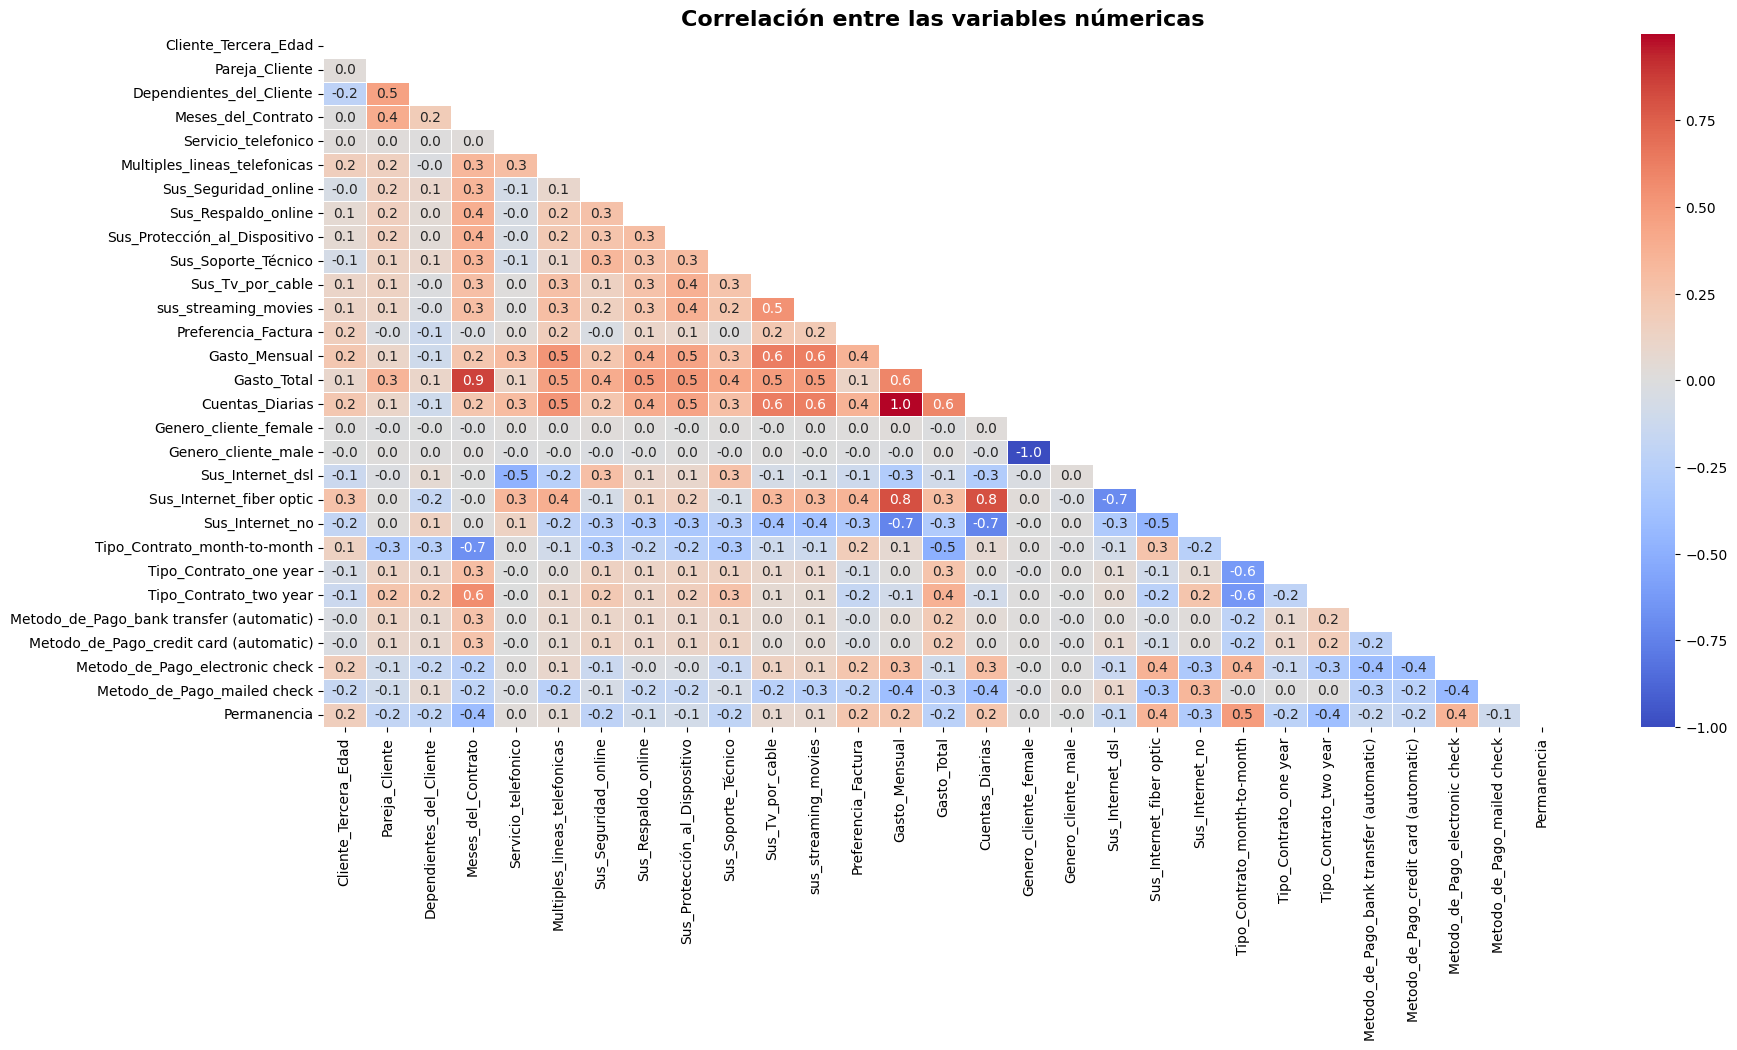

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

corr = datos.corr(numeric_only=True)

mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

fig, ax = plt.subplots(figsize=(20,9))
plt.title('Correlación entre las variables númericas', fontsize=16, fontweight='bold')

sns.heatmap(corr, mask=mascara, cmap='coolwarm', linewidths=0.5, annot=True, fmt='.1f', center=0)

plt.show()

Basándonos en la correlación, las columnas Multiples_lineas_telefonicas, y las columnas de género (Genero_cliente_male, Genero_cliente_female) tienen una correlación muy baja con la variable objetivo, por lo que podrían ser consideradas para su eliminación.

Además, debido a la posible multicolinealidad entre Gasto_Mensual, Gasto_Total y Meses_del_Contrato, es muy probable que una o dos de ellas sean redundantes. Esto debe comprobarse.

Recalcular y mostrar las 10 características con los valores de correlación absoluta más bajos respecto a la variable objetivo 'Permanencia' para identificar las que menos aportan al modelo.


In [24]:
correlacion_con_permanencia = datos.corr(numeric_only=True)['Permanencia'].abs()
correlacion_con_permanencia = correlacion_con_permanencia.drop('Permanencia') # Drop self-correlation

# Ordenar las correlaciones de menor a mayor
menor_correlacion = correlacion_con_permanencia.sort_values(ascending=True)

print("Las 10 columnas con la menor correlación absoluta con 'Permanencia':")
print(menor_correlacion.head(10))

Las 10 columnas con la menor correlación absoluta con 'Permanencia':
Genero_cliente_male              0.001945
Genero_cliente_female            0.001945
Servicio_telefonico              0.024214
Multiples_lineas_telefonicas     0.053129
sus_streaming_movies             0.071849
Sus_Tv_por_cable                 0.073785
Sus_Protección_al_Dispositivo    0.078654
Sus_Respaldo_online              0.098083
Metodo_de_Pago_mailed check      0.112518
Sus_Internet_dsl                 0.148542
Name: Permanencia, dtype: float64


Para evaluar la multicolinealidad entre 'Gasto_Mensual', 'Gasto_Total' y 'Meses_del_Contrato', calcularé y mostraré su matriz de correlación por pares. Esto indicará la fuerza y ​​la dirección de las relaciones lineales entre estas variables.

Correlación entre Gasto_Mensual, Gasto_Total y Meses_del_Contrato:
                    Gasto_Mensual  Gasto_Total  Meses_del_Contrato
Gasto_Mensual            1.000000     0.589145            0.234445
Gasto_Total              0.589145     1.000000            0.857279
Meses_del_Contrato       0.234445     0.857279            1.000000


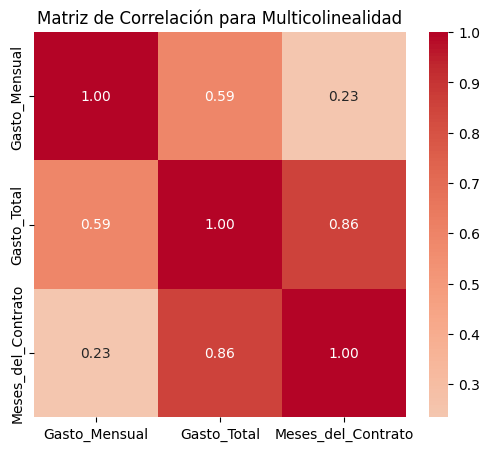

In [25]:
print("Correlación entre Gasto_Mensual, Gasto_Total y Meses_del_Contrato:")
selected_cols_multicollinearity = ['Gasto_Mensual', 'Gasto_Total', 'Meses_del_Contrato']
correlation_matrix_multicollinearity = datos[selected_cols_multicollinearity].corr(numeric_only=True)
print(correlation_matrix_multicollinearity)

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix_multicollinearity, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Matriz de Correlación para Multicolinealidad')
plt.show()

Basándonos en los resultados del análisis de correlación y multicolinealidad, las columnas que se deben eliminar son:

Columnas con muy baja correlación con 'Permanencia' (Churn):

- Genero_cliente_male
- Genero_cliente_female
- Servicio_telefonico
- Multiples_lineas_telefonicas

Estas columnas tienen una correlación casi nula con la variable objetivo, lo que indica que no aportan información significativa para predecir la cancelación del cliente.

Columna con alta multicolinealidad:

- Gasto_Total

Gasto_Total está muy altamente correlacionada con Meses_del_Contrato y Gasto_Mensual. Mantener las tres puede introducir redundancia y afectar la estabilidad de algunos modelos predictivos.

In [26]:
columnas_remover = [
    'Genero_cliente_male',
    'Genero_cliente_female',
    'Servicio_telefonico',
    'Multiples_lineas_telefonicas',
    'Gasto_Total'
]

datos_tratados = datos.copy()

# Eliminar las columnas identificadas
datos_tratados = datos_tratados.drop(columns=columnas_remover)

datos_tratados.columns

Index(['Cliente_Tercera_Edad', 'Pareja_Cliente', 'Dependientes_del_Cliente',
       'Meses_del_Contrato', 'Sus_Seguridad_online', 'Sus_Respaldo_online',
       'Sus_Protección_al_Dispositivo', 'Sus_Soporte_Técnico',
       'Sus_Tv_por_cable', 'sus_streaming_movies', 'Preferencia_Factura',
       'Gasto_Mensual', 'Cuentas_Diarias', 'Sus_Internet_dsl',
       'Sus_Internet_fiber optic', 'Sus_Internet_no',
       'Tipo_Contrato_month-to-month', 'Tipo_Contrato_one year',
       'Tipo_Contrato_two year', 'Metodo_de_Pago_bank transfer (automatic)',
       'Metodo_de_Pago_credit card (automatic)',
       'Metodo_de_Pago_electronic check', 'Metodo_de_Pago_mailed check',
       'Permanencia'],
      dtype='object')

In [27]:
datos_tratados.head(2)

,Cliente_Tercera_Edad,Pareja_Cliente,Dependientes_del_Cliente,Meses_del_Contrato,Sus_Seguridad_online,Sus_Respaldo_online,Sus_Protección_al_Dispositivo,Sus_Soporte_Técnico,Sus_Tv_por_cable,sus_streaming_movies,Preferencia_Factura,Gasto_Mensual,Cuentas_Diarias,Sus_Internet_dsl,Sus_Internet_fiber optic,Sus_Internet_no,Tipo_Contrato_month-to-month,Tipo_Contrato_one year,Tipo_Contrato_two year,Metodo_de_Pago_bank transfer (automatic),Metodo_de_Pago_credit card (automatic),Metodo_de_Pago_electronic check,Metodo_de_Pago_mailed check,Permanencia
0,0.0,1.0,1.0,-0.781266,0.0,1.0,0.0,1.0,1.0,0.0,1.0,-0.084684,-0.081202,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
1,0.0,0.0,0.0,-0.781266,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.283196,-0.279693,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0


### **Análisis Dirigido**

#### Análisis de Variables Numéricas


Visualizar la relación de 'Meses_del_Contrato', 'Gasto_Mensual' y 'Cuentas_Diarias' con la 'Permanencia' mediante boxplots para observar la distribución de estas variables en clientes que cancelan y los que no.  

Para este caso usaremos el df hasta antes de normalizar los datos ya que no estamos haciendo modelos predictivos en este paso.


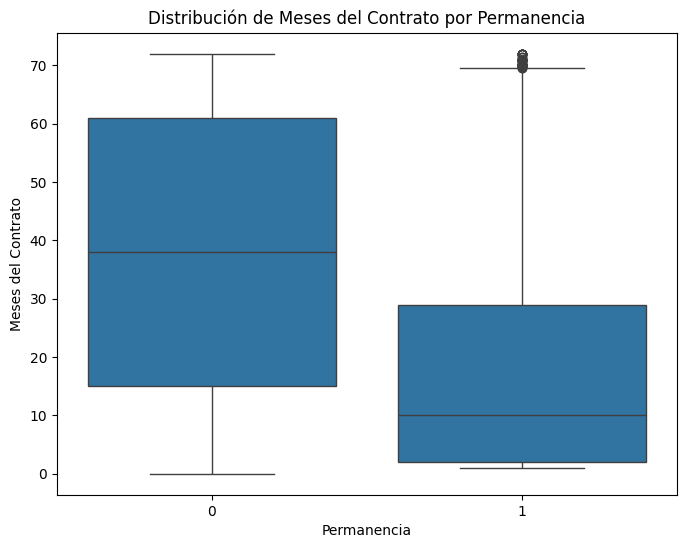

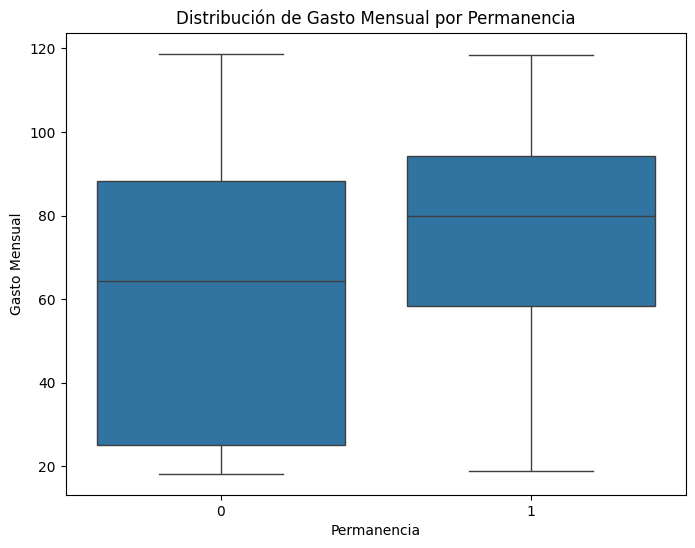

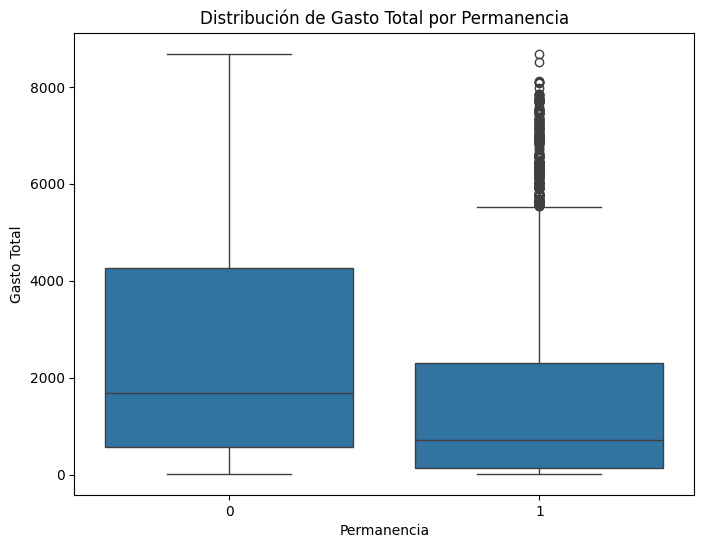

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features_for_boxplot = ['Meses_del_Contrato', 'Gasto_Mensual', 'Gasto_Total']

for col in numerical_features_for_boxplot:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Permanencia', y=col, data=datos_post_Balanceo)
    plt.title(f'Distribución de {col.replace("_", " ")} por Permanencia')
    plt.xlabel('Permanencia')
    plt.ylabel(col.replace("_", " "))
    plt.show()


**Meses_del_Contrato**

Los clientes que cancelan ('Permanencia' = 1) tienden a tener una duración de contrato significativamente menor en comparación con los clientes que no cancelan ('Permanencia' = 0). El rango intercuartílico (IQR) y la mediana para los clientes que cancelan se encuentran en valores de meses de contrato más bajos.

La duración del contrato es un factor crítico en la retención. Los clientes con contratos a corto plazo o que están en los primeros meses de su servicio son más propensos a abandonar.


**Gasto_Mensual**

Existe una tendencia donde los clientes que cancelan ('Permanencia' = 1) muestran un rango de gasto mensual ligeramente más alto en comparación con los que permanecen ('Permanencia' = 0). Aunque las distribuciones se solapan, la mediana de gasto mensual para los clientes que cancelan parece ser un poco mayor.

Esto podría indicar que los clientes con un mayor gasto mensual, posiblemente debido a servicios más complejos o paquetes premium, podrían sentirse insatisfechos si no perciben un valor adecuado por el costo, o que los altos precios pueden ser un factor para la cancelación.

**Gasto_Total**

Los clientes que cancelan ('Permanencia' = 1) tienden a tener un Gasto_Total considerablemente menor en comparación con los clientes que no cancelan ('Permanencia' = 0). Esto es esperable, ya que el gasto total es acumulativo y está fuertemente relacionado con Meses_del_Contrato.

Un menor Gasto_Total en clientes que cancelan refuerza la idea de que los clientes de corta duración (y, por lo tanto, con menor gasto acumulado) son más propensos al churn. Esto subraya la importancia de fomentar la permanencia a largo plazo para aumentar el valor de vida del cliente.


#### Análisis de Variables Categóricas

Visualizar la relación de 'Cliente_Tercera_Edad', 'Sus_Seguridad_online', 'Sus_Soporte_Técnico', y las columnas codificadas con one-hot de 'Tipo_Contrato' y 'Metodo_de_Pago' con la variable 'Permanencia' mediante countplots. Esto ayudará a entender la proporción de clientes que cancelan (churn) para cada categoría de estas variables.

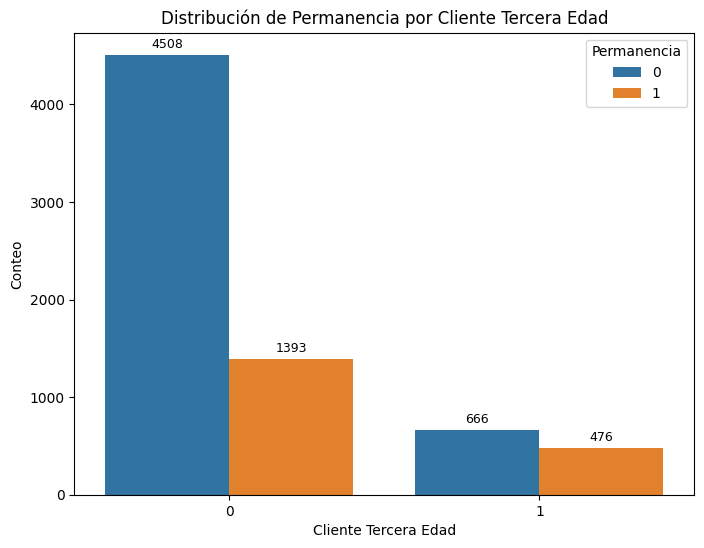

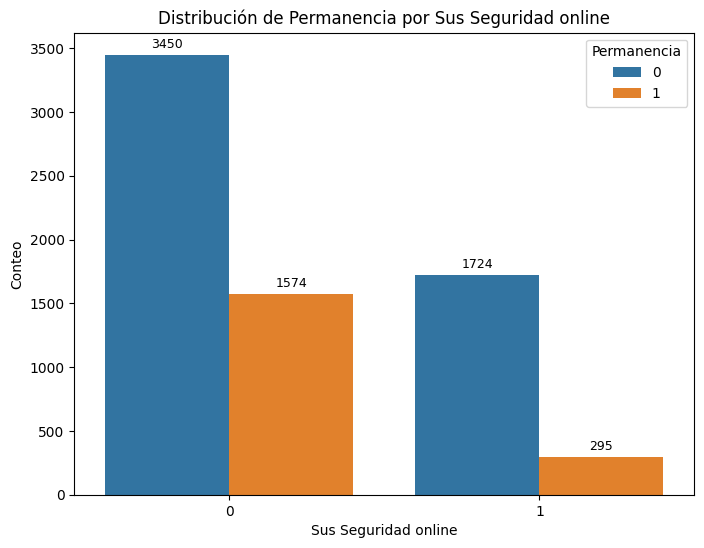

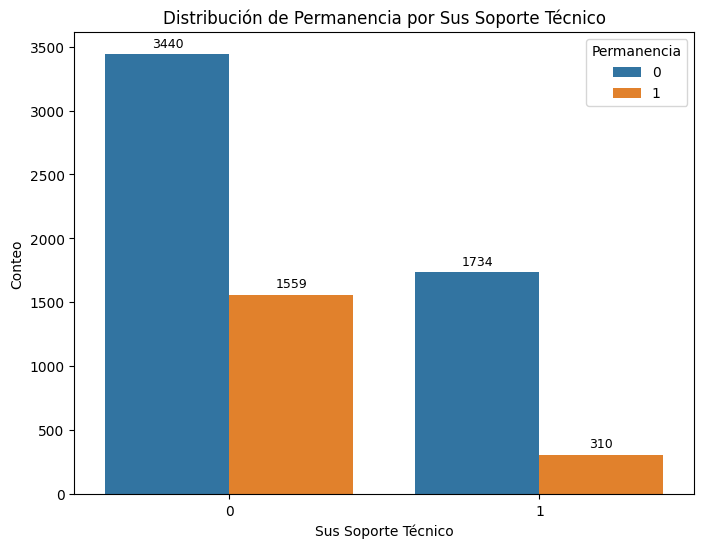

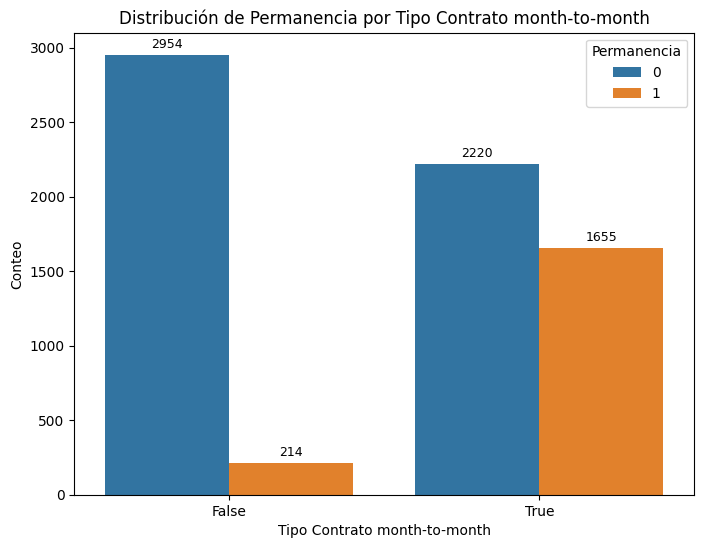

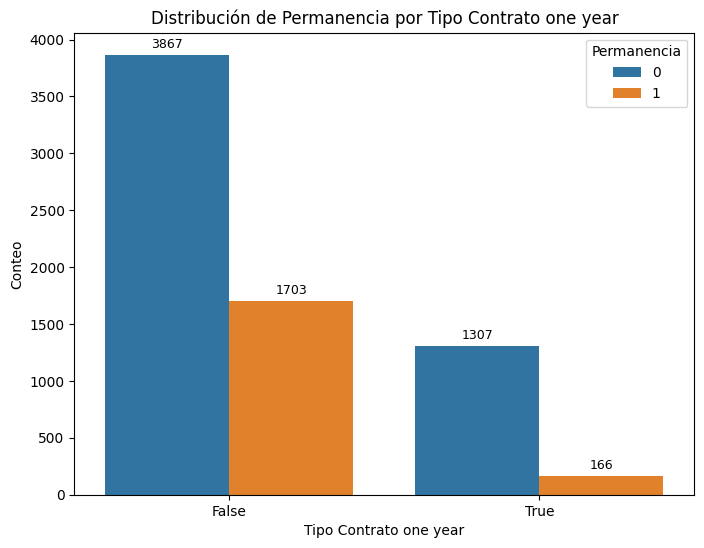

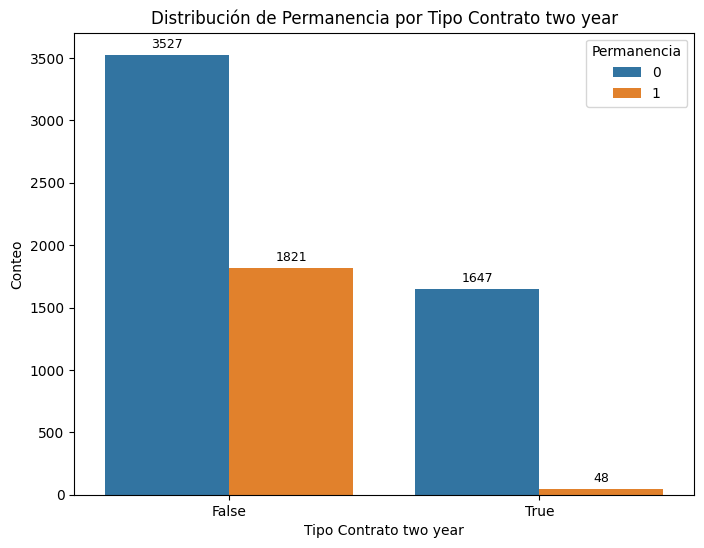

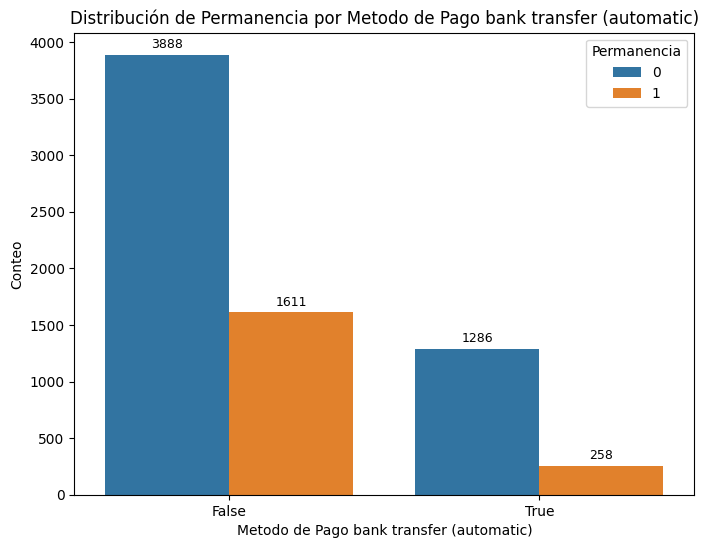

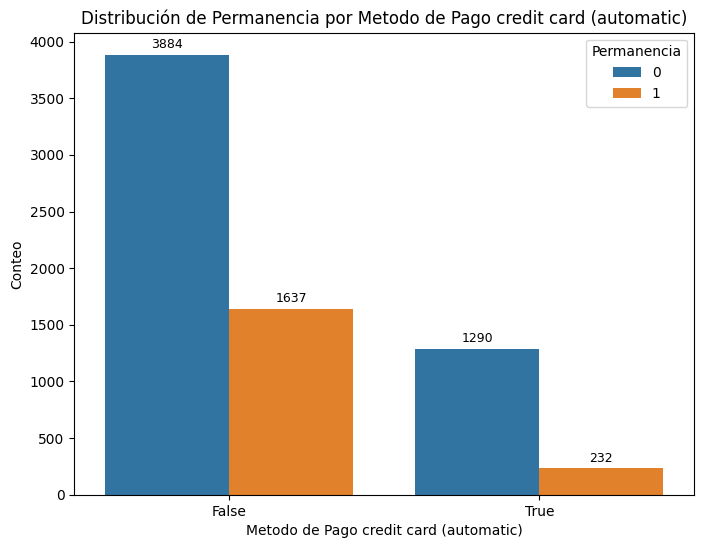

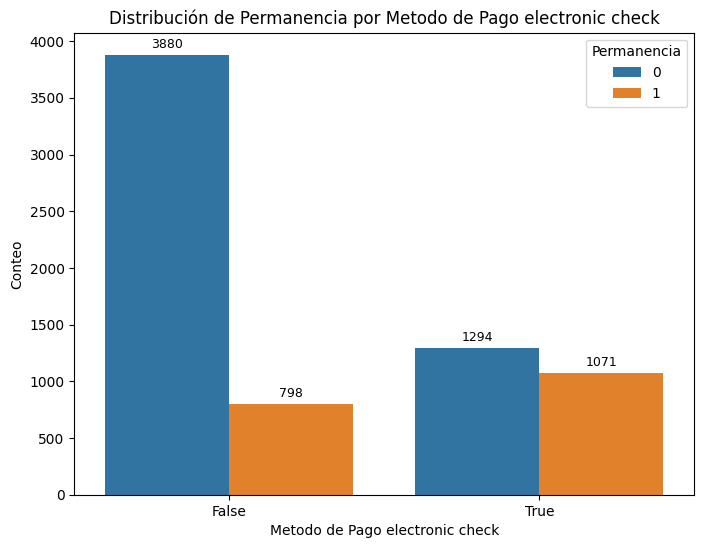

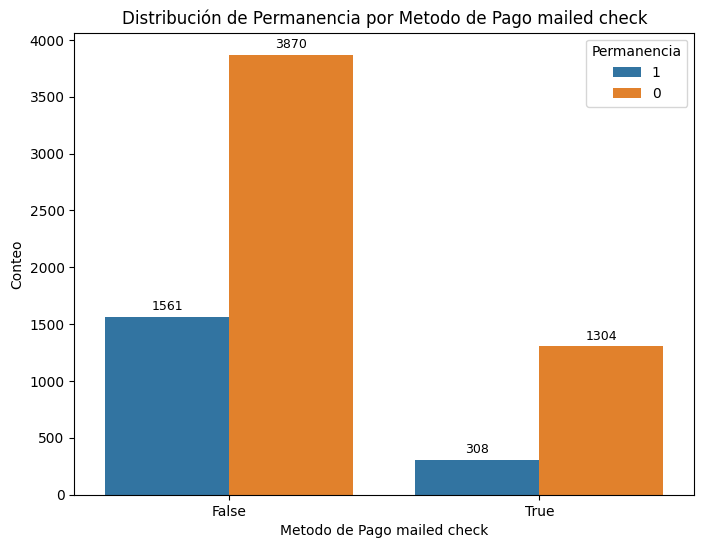

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features_for_countplot = [
    'Cliente_Tercera_Edad',
    'Sus_Seguridad_online',
    'Sus_Soporte_Técnico',
    'Tipo_Contrato_month-to-month',
    'Tipo_Contrato_one year',
    'Tipo_Contrato_two year',
    'Metodo_de_Pago_bank transfer (automatic)',
    'Metodo_de_Pago_credit card (automatic)',
    'Metodo_de_Pago_electronic check',
    'Metodo_de_Pago_mailed check'
]

for col in categorical_features_for_countplot:
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(x=col, hue='Permanencia', data=df_encoding)
    plt.title(f'Distribución de Permanencia por {col.replace("_", " ")}')
    plt.xlabel(col.replace("_", " "))
    plt.ylabel('Conteo')

    # Añadir el total del conteo encima de cada barra
    for p in ax.patches:
        height = p.get_height()
        if height > 0: # Solo anotar barras con altura positiva
            ax.annotate(f'{int(height)}',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='baseline',
                        fontsize=9, color='black', xytext=(0, 5),
                        textcoords='offset points')
    plt.show()

**Cliente Tercera Edad**

Vemos que hay una mayor cantidad de clientes que no pertencen a la tercera edad vs los que si. En cuanto a los que no son de esta categoria vemos que (4008) no permanecen, frente a 1393 que sí. Por otro lado, los que si son de la tercera edad, (666) no permanecen, frente a 476 que sí. Tanto para los clientes que son de la tercera edad como los que si, se muestra que hay mayoria en no permanencia vs los que sí.

**Seguridad Online**

Para los clientes que no contratan el servicio de seguridad online (0): 2350 no permanecen vs 1574 sí permanecen. Mientras que para los clientes que si eligen contratar este servivio Con seguridad online (1): 1724 no permanecen vs 295 sí permanecen, indicando que la seguridad online como servicio extra no aporta mucho a la permanencia de los clientes.

**Soporte Técnico**

Para los clientes que no deciden contratar el servicio de soporte técnico (0): 3440 no permanentes vs 1559 sí lo hacen. Por su parte, los cluientes que si contratan el servicio extra (1), 1734 no permanecen vs 310 sí permanecen, sugiriendo que el soporte no mejora permanencia y podría aportar a aumentar el abandono de la compañia por parte de clientes.

**Contrato Mes a Mes**

Para los clientes que no manejan su Contrato mes a mes domina la no permanencia (2554 vs 224 sí). Para aquellos que si manejan su contrato bajo esta modalidad (2220 no permanecen, 1355 sí lo hacen), observamos que entonces, dentro de los clientes que manejan este tipo de contrato hay un mayor abandono del sevicio.

**Contrato Un Año**

Para los clientes que nos manejan este tipo de contrato: 2867 no permanecen vs 1703 sí lo hacen. Para los clientes que si manejan este tipo de contrato: 1307 no permanecen vs 166 sí lo hacen, patrón similar a dos años, con retención mínima en contratos largos.

**Contrato Dos Años**

Para los clientes que nos manejan este tipo de contrato: 2327 no permanecen vs 1321 sí lo hacen. Para los clientes que si manejan este tipo de contrato: 1647 no permanecen vs 48 sí lo hacen, revelando que contratos largos tienen retención extremadamente baja.

**Pago bank transfer**

Para los clientes que no realizan su pago por banco se muestra que 3588 no permanecen vs 1511 sí lo hacen.Para los clientes que sí realizan su pago por banco se muestra alto abandono (1286 no permanecen vs 258 sí lo hacen), similar al crédito, con baja retención.

**Pago Credit Card**

Para los que no eligen el pago por tarjeta de credito, se muestran un mayor número de no permanentes (3584) sobre permanentes (1537). Para los que si escogen este metodo de pago, hay más abandono del servicio (1294 no permanencen vs 223 sí permanecen), sugiriendo que este método no favorece la retención, ya que se observa que no es un metodo de pago que sea preferido por la gran mayoria de clientes.

**Pago Cheque Electrónico**

Para los que no eligen el pago por cheque electrónico se tiene 1380 no permanecen vs 798 sí lo hacen. Para los que sí eligen el pago por cheque electrónico, equilibra (1274 no permanecen, 1071 sí lo hacen), mostrando retención moderada en este metodo de pago.

**Pago Cheque Postal**

Para los que no eligen el pago  por cheque postal, 1541 no permanecen vs 3870 sí hacen, alta retención. Para los que sí eligen este metodo se invierte (1904 no vs 308 sí), destacando cheques postales como factor de abando del servicio.



## 🤖 **MODELADO PREDICTIVO**

In [30]:
columnas_remover = [
    'Genero_cliente_male',
    'Genero_cliente_female',
    'Servicio_telefonico',
    'Multiples_lineas_telefonicas',
    'Gasto_Total'
]

datos_Balanceo = datos_post_Balanceo.copy()

# Eliminar las columnas identificadas
datos_Balanceo = datos_Balanceo.drop(columns=columnas_remover)

datos_Balanceo.columns

Index(['Cliente_Tercera_Edad', 'Pareja_Cliente', 'Dependientes_del_Cliente',
       'Meses_del_Contrato', 'Sus_Seguridad_online', 'Sus_Respaldo_online',
       'Sus_Protección_al_Dispositivo', 'Sus_Soporte_Técnico',
       'Sus_Tv_por_cable', 'sus_streaming_movies', 'Preferencia_Factura',
       'Gasto_Mensual', 'Cuentas_Diarias', 'Sus_Internet_dsl',
       'Sus_Internet_fiber optic', 'Sus_Internet_no',
       'Tipo_Contrato_month-to-month', 'Tipo_Contrato_one year',
       'Tipo_Contrato_two year', 'Metodo_de_Pago_bank transfer (automatic)',
       'Metodo_de_Pago_credit card (automatic)',
       'Metodo_de_Pago_electronic check', 'Metodo_de_Pago_mailed check',
       'Permanencia'],
      dtype='object')

In [31]:
from sklearn.model_selection import train_test_split

# Separar las características (X) y la variable objetivo (y)
X = datos_Balanceo.drop('Permanencia', axis=1)
y = datos_Balanceo['Permanencia']

# Dividir el conjunto de datos en entrenamiento y prueba (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Dimensiones de los conjuntos de entrenamiento:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nDimensiones de los conjuntos de prueba:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Dimensiones de los conjuntos de entrenamiento:
X_train: (7243, 23)
y_train: (7243,)

Dimensiones de los conjuntos de prueba:
X_test: (3105, 23)
y_test: (3105,)


### **Creación de Modelos**

**Modelo de referencia - Baseline**

In [32]:
from sklearn.dummy import DummyClassifier

In [33]:
dummy = DummyClassifier()
dummy.fit(X_train, y_train)

dummy.score(X_test, y_test)

0.4885668276972625

**Árbol de Decisión**

In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
modelo_arbol = DecisionTreeClassifier(max_depth=10,random_state =5)
modelo_arbol.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, random_state=5)

In [36]:
modelo_arbol.predict(X_test)

array([1, 0, 1, ..., 1, 0, 0])

In [37]:
modelo_arbol.score(X_test, y_test)

0.8241545893719807

In [38]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [39]:
valores_columnas = ['Cliente_Tercera_Edad', 'Pareja_Cliente', 'Dependientes_del_Cliente',
       'Meses_del_Contrato', 'Sus_Seguridad_online', 'Sus_Respaldo_online',
       'Sus_Protección_al_Dispositivo', 'Sus_Soporte_Técnico',
       'Sus_Tv_por_cable', 'sus_streaming_movies', 'Preferencia_Factura',
       'Gasto_Mensual', 'Cuentas_Diarias', 'Sus_Internet_dsl',
       'Sus_Internet_fiber optic', 'Sus_Internet_no',
       'Tipo_Contrato_month-to-month', 'Tipo_Contrato_one year',
       'Tipo_Contrato_two year', 'Metodo_de_Pago_bank transfer (automatic)',
       'Metodo_de_Pago_credit card (automatic)',
       'Metodo_de_Pago_electronic check', 'Metodo_de_Pago_mailed check',
       'Permanencia']

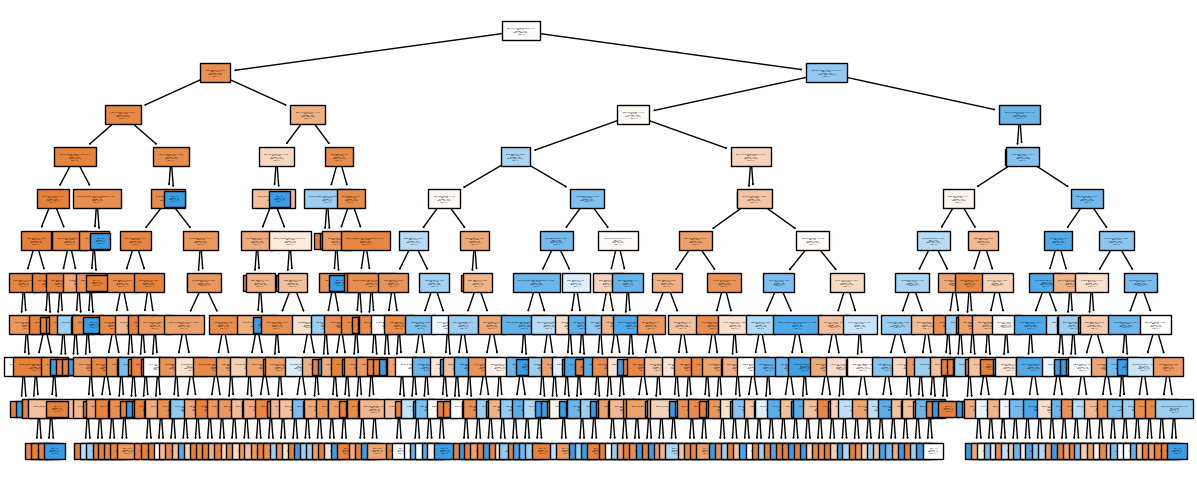

In [40]:
plt.figure(figsize = (15, 6))
plot_tree(modelo_arbol, filled = True, class_names = ['no', 'si'], fontsize = 1, feature_names = valores_columnas);

**KNN**

In [41]:
from sklearn.preprocessing import MinMaxScaler
normalizacion = MinMaxScaler()
X_train_normalizado = normalizacion.fit_transform(X_train)
pd.DataFrame(X_train_normalizado)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22
0,0.829821,0.000000,0.000000,0.027778,0.000000,0.0,0.000000,0.0,1.0,1.0,1.000000,0.757118,0.755795,0.0,1.0,0.0,1.0,0.0,0.0,0.000000,0.0,1.000000,0.000000
1,0.000000,0.000000,0.322848,0.013889,0.322848,0.0,0.677152,0.0,0.0,0.0,0.322848,0.550072,0.549254,0.0,1.0,0.0,1.0,0.0,0.0,0.677152,0.0,0.000000,0.322848
2,0.000000,0.000000,0.000000,0.666667,0.000000,1.0,0.000000,0.0,0.0,0.0,0.000000,0.566169,0.567164,0.0,1.0,0.0,0.0,1.0,0.0,0.000000,0.0,1.000000,0.000000
3,1.000000,1.000000,0.000000,0.569444,1.000000,0.0,1.000000,0.0,0.0,0.0,1.000000,0.651741,0.650746,0.0,1.0,0.0,1.0,0.0,0.0,1.000000,0.0,0.000000,0.000000
4,1.000000,0.000000,0.000000,0.527778,1.000000,1.0,0.000000,0.0,0.0,0.0,1.000000,0.387065,0.385075,1.0,0.0,0.0,1.0,0.0,0.0,0.000000,1.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7238,0.000000,1.000000,1.000000,0.930556,1.000000,0.0,0.000000,1.0,0.0,0.0,0.000000,0.173632,0.173134,1.0,0.0,0.0,0.0,0.0,1.0,0.000000,1.0,0.000000,0.000000
7239,0.000000,0.000000,0.000000,0.013889,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.008955,0.008955,0.0,0.0,1.0,1.0,0.0,0.0,0.000000,0.0,0.000000,1.000000
7240,0.000000,0.000000,0.000000,0.013889,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.012935,0.011940,0.0,0.0,1.0,1.0,0.0,0.0,0.000000,0.0,0.000000,1.000000
7241,0.000000,1.000000,1.000000,0.722222,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.065174,0.065672,0.0,0.0,1.0,0.0,0.0,1.0,0.000000,0.0,0.000000,1.000000


In [42]:
from sklearn.neighbors import KNeighborsClassifier

In [43]:
knn = KNeighborsClassifier()

In [44]:
knn.fit(X_train_normalizado, y_train)

KNeighborsClassifier()

In [45]:
X_test_normalizado = normalizacion.transform(X_test)

In [46]:
knn.score(X_test_normalizado, y_test)

0.7697262479871175

### **Evaluación de los Modelos**

In [47]:
print(f'Exactitud Dummy: {dummy.score(X_test, y_test)}')
print(f'Exactitud modelo_arbol: {modelo_arbol.score(X_test, y_test)}')
print(f'Exactitud KNN: {knn.score(X_test_normalizado, y_test)}')

Exactitud Dummy: 0.4885668276972625
Exactitud modelo_arbol: 0.8241545893719807
Exactitud KNN: 0.7697262479871175


In [48]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

y_dummy_predict = dummy.predict(X_test)
y_arbol_predict = modelo_arbol.predict(X_test)
y_knn_predict = knn.predict(X_test_normalizado)


resultados = (pd.DataFrame({
    'Modelo' : ['Dummy', 'Decision Tree', 'KNN'],
    'Accuracy':[
        accuracy_score(y_test, y_dummy_predict),
        accuracy_score(y_test, y_arbol_predict),
        accuracy_score(y_test, y_knn_predict)
    ],
    'Recall' : [
        recall_score(y_test, y_dummy_predict),
        recall_score(y_test, y_arbol_predict),
        recall_score(y_test, y_knn_predict)
    ],
    'Precision' : [
        precision_score(y_test, y_dummy_predict),
        precision_score(y_test, y_arbol_predict),
        precision_score(y_test, y_knn_predict),
    ],
    'F1': [
        f1_score(y_test, y_dummy_predict),
        f1_score(y_test, y_arbol_predict),
        f1_score(y_test, y_knn_predict)
    ]
})).round(2)


resultados

,Modelo,Accuracy,Recall,Precision,F1
0,Dummy,0.49,1.00,0.49,0.66
1,Decision Tree,0.82,0.82,0.82,0.82
2,KNN,0.77,0.85,0.72,0.78


**Matriz de Confusión**

In [49]:
from sklearn.metrics import ConfusionMatrixDisplay

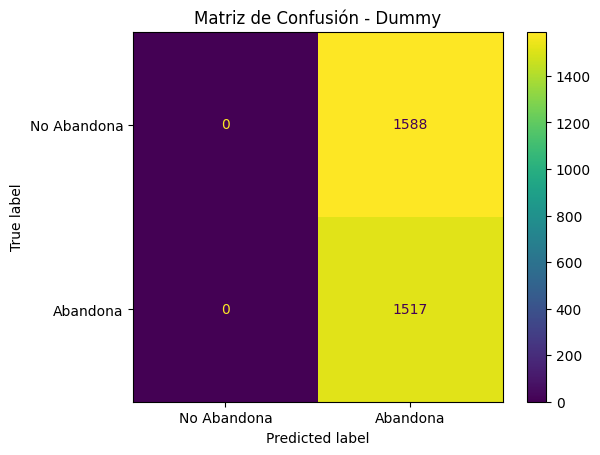

In [50]:
ConfusionMatrixDisplay.from_predictions(y_test, y_dummy_predict, display_labels=["No Abandona", "Abandona"])
plt.title('Matriz de Confusión - Dummy')
plt.show()

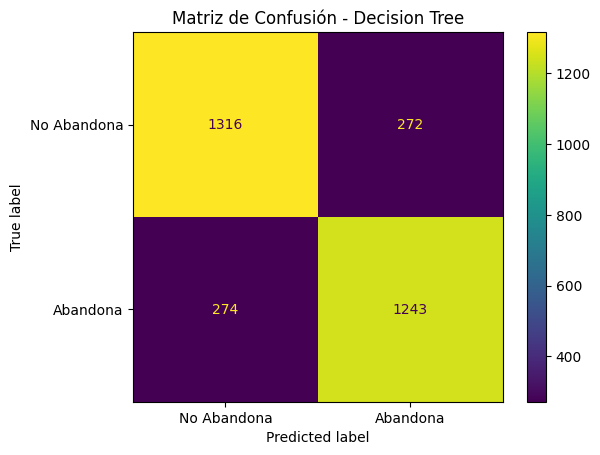

In [51]:
ConfusionMatrixDisplay.from_predictions(y_test,y_arbol_predict, display_labels=["No Abandona", "Abandona"])

plt.title("Matriz de Confusión - Decision Tree")
plt.show()

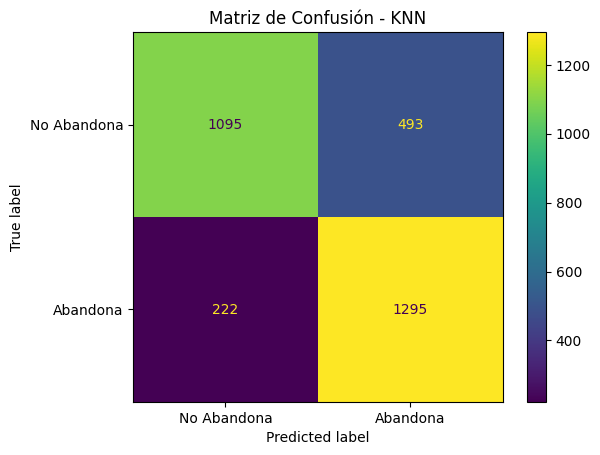

In [52]:
ConfusionMatrixDisplay.from_predictions(y_test, y_knn_predict, display_labels=["No Abandona", "Abandona"])

plt.title("Matriz de Confusión - KNN")
plt.show()


### **Análisis de la Importancia de las Variables**

**KNN**

In [56]:
from sklearn.inspection import permutation_importance

resultados = permutation_importance(
    knn,
    X_test_normalizado,
    y_test,
    n_repeats=10,
    random_state=123,
    scoring='recall'
)

nombre_columnas = X.columns

importancia_knn = pd.Series(resultados.importances_mean, index=nombre_columnas)
importancia_knn.sort_values(ascending=False)

,0
Meses_del_Contrato,0.068029
Pareja_Cliente,0.023797
Sus_Respaldo_online,0.022149
Cuentas_Diarias,0.021424
Gasto_Mensual,0.019183
Preferencia_Factura,0.018523
Sus_Tv_por_cable,0.015359
Dependientes_del_Cliente,0.013250
Sus_Seguridad_online,0.013118
Sus_Soporte_Técnico,0.009295


**Modelo Árbol**

In [60]:
from sklearn.inspection import permutation_importance

resultados_arbol = permutation_importance(
    modelo_arbol,
    X_test,
    y_test,
    n_repeats=10,
    random_state=123,
    scoring='recall'
)

nombre_columnas = X.columns

importancia_arbol = pd.Series(resultados_arbol.importances_mean, index=nombre_columnas)
importancia_arbol.sort_values(ascending=False)

,0
Tipo_Contrato_month-to-month,0.210679
Sus_Internet_fiber optic,0.087409
Meses_del_Contrato,0.077060
Metodo_de_Pago_electronic check,0.041134
Sus_Internet_no,0.028609
Sus_Seguridad_online,0.028279
Preferencia_Factura,0.026236
Sus_Soporte_Técnico,0.012591
Pareja_Cliente,0.007119
Metodo_de_Pago_credit card (automatic),0.005537


## 📋 **INTERPRETACIÓN Y CONCLUSIONES**

### **Análisis de la Importancia de las Variables**

### **KNN**

In [58]:
print("Importancia de las características para el modelo KNN (Recall):")
print(importancia_knn.sort_values(ascending=False))

Importancia de las características para el modelo KNN (Recall):
Meses_del_Contrato                          0.068029
Pareja_Cliente                              0.023797
Sus_Respaldo_online                         0.022149
Cuentas_Diarias                             0.021424
Gasto_Mensual                               0.019183
Preferencia_Factura                         0.018523
Sus_Tv_por_cable                            0.015359
Dependientes_del_Cliente                    0.013250
Sus_Seguridad_online                        0.013118
Sus_Soporte_Técnico                         0.009295
Cliente_Tercera_Edad                        0.007449
Sus_Protección_al_Dispositivo               0.007383
sus_streaming_movies                        0.005933
Tipo_Contrato_two year                     -0.001384
Tipo_Contrato_month-to-month               -0.003626
Tipo_Contrato_one year                     -0.004680
Sus_Internet_fiber optic                   -0.004812
Metodo_de_Pago_credit card (automat

Basándonos en los resultados de la importancia por permutación para el modelo KNN, medido por el recall, podemos observar lo siguiente:

**Características más impactantes (Importancia positiva más alta):**

1.  **Meses_del_Contrato (0.068029):** Esta es, con diferencia, la característica más importante para el modelo KNN. Una mayor duración del contrato parece ser un fuerte indicador de permanencia o no cancelación, lo cual es coherente con análisis previos.
2.  **Pareja_Cliente (0.023797):** La presencia de una pareja en el contrato también muestra una importancia considerable, sugiriendo que los clientes con pareja son menos propensos a cancelar.
3.  **Sus_Respaldo_online (0.022149):** Tener el servicio de respaldo online es la tercera característica más importante, indicando que este servicio contribuye a la retención de clientes.
4.  **Cuentas_Diarias (0.021424) y Gasto_Mensual (0.019183):** Ambas variables financieras muestran una importancia significativa, lo que implica que el patrón de gasto del cliente es relevante para el modelo KNN.

Otras características con importancia positiva, aunque menor, incluyen Preferencia_Factura, Sus_Tv_por_cable, Dependientes_del_Cliente, Sus_Seguridad_online, Sus_Soporte_Técnico, Cliente_Tercera_Edad, Sus_Protección_al_Dispositivo y sus_streaming_movies.

**Características con baja o negativa importancia:**

Varias características categóricas codificadas con one-hot, especialmente las relacionadas con el tipo de contrato y el método de pago, muestran una importancia muy baja o incluso negativa. Una importancia negativa sugiere que la aleatorización de esta característica en el conjunto de prueba perjudicó el rendimiento del modelo (en este caso, el recall), lo que puede indicar que la característica en sí no es muy informativa o que su relación con la variable objetivo es compleja y no capturada eficientemente por el modelo KNN con la métrica de recall utilizada.

Las características con importancia negativa incluyen:

*   Tipo_Contrato_two year
*   Tipo_Contrato_month-to-month
*   Tipo_Contrato_one year
*   Sus_Internet_fiber optic
*   Metodo_de_Pago_credit card (automatic)
*   Sus_Internet_no
*   Sus_Internet_dsl
*   Metodo_de_Pago_bank transfer (automatic)
*   Metodo_de_Pago_mailed check
*   Metodo_de_Pago_electronic check

Es importante destacar que el método de pago 'electronic check' muestra la importancia negativa más pronunciada (-0.028873), lo que podría sugerir que, para el modelo KNN, esta característica no ayuda a identificar correctamente a los clientes que abandonan.

### **Arbol de Decisión**

In [59]:
print("Importancia de las características para el modelo de Árbol de Decisión (Recall):")
print(importancia_arbol.sort_values(ascending=False))

Importancia de las características para el modelo de Árbol de Decisión (Recall):
Tipo_Contrato_month-to-month                0.210679
Sus_Internet_fiber optic                    0.087409
Meses_del_Contrato                          0.077060
Metodo_de_Pago_electronic check             0.041134
Sus_Internet_no                             0.028609
Sus_Seguridad_online                        0.028279
Preferencia_Factura                         0.026236
Sus_Soporte_Técnico                         0.012591
Pareja_Cliente                              0.007119
Metodo_de_Pago_credit card (automatic)      0.005537
Tipo_Contrato_one year                      0.004153
Dependientes_del_Cliente                    0.003889
Cliente_Tercera_Edad                        0.003757
Tipo_Contrato_two year                      0.002109
sus_streaming_movies                        0.001516
Sus_Protección_al_Dispositivo               0.001187
Sus_Respaldo_online                         0.000923
Sus_Tv_por_cable  

Basándonos en los resultados de la importancia por permutación para el modelo de Árbol de Decisión, medido por el recall, podemos observar lo siguiente:

**Características más impactantes (Importancia positiva más alta):**

1.  **Tipo_Contrato_month-to-month (0.210679):** Esta es la característica más importante para el modelo de Árbol de Decisión, con una importancia significativamente mayor que las demás. Esto sugiere que el tipo de contrato mensual es un predictor muy fuerte de la permanencia del cliente, indicando que los clientes con contratos mes a mes son mucho más propensos a cancelar.
2.  **Sus_Internet_fiber optic (0.087409):** La conexión a internet por fibra óptica es la segunda característica más relevante, lo que podría implicar que los clientes con este tipo de servicio tienen un patrón de permanencia diferente o expectativas específicas que, si no se cumplen, llevan al churn.
3.  **Meses_del_Contrato (0.077060):** La duración del contrato sigue siendo una característica muy importante, aunque ligeramente menos que para el modelo KNN, lo que subraya su relevancia general en la predicción del churn.
4.  **Metodo_de_Pago_electronic check (0.041134):** Este método de pago también muestra una importancia considerable, indicando que los clientes que utilizan el cheque electrónico tienen una probabilidad distinta de permanencia.

Otras características con importancia positiva, aunque menor, incluyen Sus_Internet_no, Sus_Seguridad_online, Preferencia_Factura, Sus_Soporte_Técnico, Pareja_Cliente, Metodo_de_Pago_credit card (automatic), Tipo_Contrato_one year, Dependientes_del_Cliente, Cliente_Tercera_Edad, Tipo_Contrato_two year, sus_streaming_movies, Sus_Protección_al_Dispositivo, Sus_Respaldo_online, Sus_Tv_por_cable, Metodo_de_Pago_bank transfer (automatic), y Sus_Internet_dsl.

**Características con baja o negativa importancia:**

Al igual que en el modelo KNN, algunas características muestran una importancia muy baja o negativa. Una importancia negativa sugiere que la aleatorización de esta característica en el conjunto de prueba perjudicó el rendimiento del modelo (recall), lo que indica que no es informativa o que su relación es compleja y el modelo de árbol no la utiliza eficazmente para mejorar el recall.

Las características con importancia negativa incluyen:

*   Metodo_de_Pago_mailed check (-0.000264)
*   Gasto_Mensual (-0.004285)
*   Cuentas_Diarias (-0.012854)

Es particularmente notable que **Gasto_Mensual** y **Cuentas_Diarias**, que tenían una importancia positiva moderada en el modelo KNN, muestren una importancia negativa en el Árbol de Decisión. Esto puede deberse a que el Árbol de Decisión prioriza otras características más discriminatorias (como el tipo de contrato) o que la relación de estas variables con el churn es capturada por otras características a través de las divisiones del árbol, haciendo que su impacto directo sea menor o incluso perjudicial para el recall cuando se permutan.

### **Comparación y Conclusión**

Al comparar los resultados de la importancia de las características para el modelo KNN y el modelo de Árbol de Decisión, ambos medidos por el recall, podemos observar diferencias y similitudes clave:

**Variables Consistentemente Importantes (en ambos modelos):**

*   **Meses_del_Contrato:** Esta característica emerge como un predictor consistently fuerte en ambos modelos. Para el KNN fue la más importante (0.068), y para el Árbol de Decisión fue la tercera más importante (0.077). Esto subraya que la duración de la relación del cliente con el servicio es un factor crítico para predecir el churn.
*   **Pareja_Cliente:** Tuvo una importancia positiva notable en ambos modelos (KNN: 0.024, Árbol: 0.007). Esto sugiere que la presencia de una pareja influye en la permanencia del cliente.

**Variables con Mayor Impacto en el Árbol de Decisión:**

*   **Tipo_Contrato_month-to-month:** Es, por lejos, la característica más influyente para el Árbol de Decisión (0.211). Esto indica que los clientes con contratos mensuales tienen una probabilidad significativamente mayor de cancelar, y el modelo de árbol lo utiliza fuertemente para hacer sus divisiones. Esto era menos pronunciado en el KNN.
*   **Sus_Internet_fiber optic:** También muestra una alta importancia para el Árbol de Decisión (0.087), siendo el segundo factor más importante. Esto sugiere una fuerte conexión entre el tipo de servicio de internet y la propensión a cancelar.
*   **Metodo_de_Pago_electronic check:** Es notablemente más importante para el Árbol de Decisión (0.041) que para el KNN (donde incluso tuvo una importancia negativa de -0.029). Esto resalta cómo los diferentes modelos interpretan y utilizan las características de manera distinta. Para el árbol, este método de pago es un factor diferenciador.

**Variables con Mayor Impacto en KNN:**

*   **Sus_Respaldo_online, Cuentas_Diarias, Gasto_Mensual:** Estas variables financieras y de servicio fueron más influyentes para el modelo KNN (con importancias de 0.022, 0.021 y 0.019 respectivamente) que para el Árbol de Decisión (donde Gasto_Mensual y Cuentas_Diarias incluso mostraron importancia negativa, y Sus_Respaldo_online fue muy baja con 0.0009). Esto sugiere que el KNN, al ser un modelo basado en la distancia, es más sensible a las variaciones numéricas de estas características después de la estandarización.

**Variables con Importancia Baja o Negativa:**

*   Varias características codificadas con one-hot, especialmente relacionadas con los métodos de pago (excepto el cheque electrónico en el árbol) y algunos tipos de internet/contrato, mostraron baja o negativa importancia en ambos modelos, aunque con variaciones. La importancia negativa puede indicar que la aleatorización de esas características perjudica la capacidad del modelo para predecir correctamente el recall, o que el modelo encuentra redundancia con otras variables. Es interesante notar que Gasto_Mensual y Cuentas_Diarias tuvieron importancia negativa en el Árbol de Decisión, a pesar de ser relevantes para el KNN, lo que sugiere que su información podría estar siendo capturada por otras características clave del árbol (como el tipo de contrato y meses de contrato).

**Conclusión sobre las Variables Más Impactantes para Predecir Churn:**

Considerando ambos modelos, las variables más impactantes para predecir el churn son:

1.  **Meses_del_Contrato:** La duración del contrato es el predictor más robusto y consistente, independientemente del modelo. Los clientes con menos tiempo de contrato son más propensos a cancelar.
2.  **Tipo_Contrato_month-to-month:** El tipo de contrato mensual es un fuerte indicador de churn, especialmente para modelos basados en reglas como el Árbol de Decisión.
3.  **Sus_Internet_fiber optic:** La presencia de fibra óptica como servicio de internet también es un factor importante, sugiriendo un perfil de cliente más propenso a cancelar si no se cumplen sus expectativas.
4.  **Metodo_de_Pago_electronic check:** Este método de pago está fuertemente asociado con el churn, lo que sugiere que los clientes que lo utilizan tienen una mayor propensión a cancelar.

Estas variables deberían ser el foco principal para futuras estrategias de retención de clientes y para el desarrollo de modelos predictivos más avanzados.

### **CONCLUSIÓN**

**Hallazgos Clave del Análisis de Datos**

El análisis identificó cinco factores clave fuertemente asociados con la cancelación de clientes, indicando áreas donde se necesitan estrategias de retención dirigidas:

- **Tipo de Contrato:** Los clientes con contratos mes a mes y aquellos con duraciones de contrato más cortas (implícito en 'Meses_del_Contrato') son más propensos a cancelar.

- **Tipo de Servicio:** Los suscriptores de servicios de internet de fibra óptica muestran una mayor propensión a cancelar.

- **Método de Pago:** Los clientes que utilizan cheques electrónicos como método de pago están en mayor riesgo de cancelar.

- **Estado de Relación del Cliente:** Los clientes identificados con pareja (Pareja_Cliente) también son más propensos a cancelar.


**Ideas o Próximos Pasos**

- **Incentivar Compromisos a Largo Plazo:** Para abordar la cancelación relacionada con contratos a corto plazo y mes a mes, ofrecer descuentos atractivos, recompensas por lealtad o servicios empaquetados para los clientes que opten por planes de contrato a largo plazo (por ejemplo, acuerdos de 12 o 24 meses).

- **Mejorar el Valor y Soporte del Servicio de Fibra Óptica:** Investigar los puntos débiles específicos para los suscriptores de internet de fibra óptica (por ejemplo, confiabilidad del servicio, consistencia de la velocidad o problemas de soporte al cliente) que contribuyen a su mayor tasa de cancelación. Implementar mejoras y comunicar propuestas de valor mejoradas o beneficios exclusivos para estos usuarios.

- **Promover Métodos de Pago Automatizados:** Animar a los clientes que pagan con cheque electrónico a cambiar a métodos de pago automatizados más convenientes y confiables (por ejemplo, pago automático con tarjeta de crédito, débito directo) ofreciendo pequeños incentivos o destacando los beneficios de un servicio ininterrumpido y una fácil gestión.

- **Adaptar Ofertas para Clientes con Pareja:** Explorar las necesidades o motivaciones específicas de los clientes con pareja que conducen a una mayor cancelación. Considerar el desarrollo de planes orientados a la familia, descuentos multiusuario o servicios empaquetados que atiendan a hogares con múltiples tomadores de decisiones o usuarios, y asegurar que la comunicación resalte estos beneficios.